# ResNet50 on ROI mammogram data

Local training notebook with unified preprocessing and augmentation for fair model comparison.

In [6]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import regularizers
import os
import random
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
import matplotlib.pyplot as plt
import numpy as np

TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
data_dir = "/mnt/e/DDSM/ROI"
assert os.path.exists(data_dir), f"Dataset path not found: {data_dir}"
print("Using data_dir:", data_dir)


Using data_dir: /mnt/e/DDSM/ROI


In [8]:

img_size = (224, 224)
batch_size = 16
seed = 123
AUTOTUNE = tf.data.AUTOTUNE

os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
keras.utils.set_random_seed(seed)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

# 1) Dataset split: train / val / test
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("class_name:", class_names)

temp_card = tf.data.experimental.cardinality(temp_ds).numpy()
val_batches = temp_card // 2
val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

def prepare(ds, shuffle=False, cache_path=None):
    if shuffle:
        ds = ds.shuffle(1000, seed=seed, reshuffle_each_iteration=True)
    if cache_path:
        ds = ds.cache(cache_path)
    return ds.prefetch(AUTOTUNE)
train_ds_prep = prepare(train_ds, shuffle=True, cache_path="/tmp/train_cache")
val_ds_prep   = prepare(val_ds, cache_path="/tmp/val_cache")
test_ds_prep  = prepare(test_ds, cache_path="/tmp/test_cache")

print("train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("val   batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("test  batches:", tf.data.experimental.cardinality(test_ds).numpy())



# 2) Model: augmentation + ResNet50 + classification head (with regularization)

data_augmentation = keras.Sequential(
    [
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.10),
        keras.layers.RandomZoom(0.20),
        keras.layers.RandomTranslation(0.05, 0.05),
        keras.layers.RandomContrast(0.20),
    ],
    name="data_augmentation"
)

base_model = keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=img_size + (3,)
)

preprocessing = keras.Sequential(
    [keras.layers.Rescaling(1.0 / 255)],
    name="preprocessing"
)

inputs = keras.Input(shape=img_size + (3,))
x = preprocessing(inputs)
x = data_augmentation(x)  # Active only during training

# Keep BN in inference mode during the frozen stage for stability
x = base_model(x, training=False)

x = keras.layers.GlobalAveragePooling2D()(x)

# Use a larger dropout rate: 0.5
x = keras.layers.Dropout(0.5)(x)


l2 = tf.keras.regularizers.l2(1e-4)
outputs = keras.layers.Dense(
    1, activation="sigmoid",
    kernel_regularizer=l2,  # Apply L2 regularization to Dense weights
    bias_regularizer=None
)(x)

model = keras.Model(inputs, outputs)



# 3) Stage 1: freeze the backbone and train only the head

loss_fn = keras.losses.BinaryCrossentropy()

stage1_ckpt = "best_resnet_stage1.keras"
callbacks_stage1 = [
    keras.callbacks.ModelCheckpoint(
        stage1_ckpt,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=3, restore_best_weights=True
    )
]

initial_epochs = 8
base_model.trainable = False
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=loss_fn,  # Use label smoothing with factor 0.05
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

history1 = model.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=initial_epochs,
    callbacks=callbacks_stage1
)

# 4) Stage 2: unfreeze only conv5_* and keep all BN layers frozen
base_model.trainable = False

for layer in base_model.layers:
    if layer.name.startswith("conv5_"):
        layer.trainable = True

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Total base_model layers:", len(base_model.layers))
print("Trainable layers:", sum(int(l.trainable) for l in base_model.layers))

best_path = "best_by_val_auc.keras"

# Reduce the learning rate automatically when val_auc stops improving
callbacks_stage2 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=best_path,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,     # learning rate * 0.5
        patience=2,     # reduce after 2 epochs without improvement
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=6,     # slightly relaxed patience to work with LR scheduling
        restore_best_weights=False,  # rely on the checkpoint file instead
        verbose=1
    ),
]

# Use AdamW
try:
    opt2 = keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-5)
except Exception:
    opt2 = keras.optimizers.Adam(learning_rate=1e-5)

fine_tune_epochs = 50
total_epochs = initial_epochs + fine_tune_epochs

model.compile(
    optimizer=opt2,  # Prefer AdamW
    loss=loss_fn,   # Includes label smoothing
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

history2 = model.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=total_epochs,
    initial_epoch=initial_epochs,
    callbacks=callbacks_stage2
)

print("Training complete. Best checkpoint saved to:", best_path)


Found 2830 files belonging to 2 classes.
Using 2264 files for training.
Found 2830 files belonging to 2 classes.
Using 566 files for validation.
class_name: ['ROI_Benign', 'ROI_Cancer']
train batches: 142
val   batches: 18
test  batches: 18
Epoch 1/8
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5096 - auc: 0.5189 - loss: 0.7429
Epoch 1: val_auc improved from None to 0.55622, saving model to best_resnet_stage1.keras

Epoch 1: finished saving model to best_resnet_stage1.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 35s 177ms/step - accuracy: 0.5093 - auc: 0.5135 - loss: 0.7397 - val_accuracy: 0.4931 - val_auc: 0.5562 - val_loss: 0.6928
Epoch 2/8
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5065 - auc: 0.5025 - loss: 0.7309
Epoch 2: val_auc did not improve from 0.55622
142/142 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.5106 - auc: 0.5002 - loss: 0.7322 - val_accuracy: 0.4931 - val_auc: 0.5555 - val_loss: 0.6924
Epoch 3/8
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accura

In [10]:
best_model = keras.models.load_model("/mnt/e/SW_training_outputs/checkpoints/best_vit_model.keras")


/home/dell/miniconda3/envs/tf218/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/dell/miniconda3/envs/tf218/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 410 variables whereas the saved optimizer has 82 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


2026-03-11 16:11:24.327775: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-03-11 16:11:26.265147: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-03-11 16:11:29.775593: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute us

Positive class for ROC/AUC: ROI_Cancer
First 20 val_true: [1 1 0 0 1 1 0 0 0 1 0 0 1 1 1 0 0 0 0 1]
First 20 val_prob: [0.7925 0.3264 0.284  0.3884 0.9108 0.3158 0.3461 0.5354 0.1627 0.4824
 0.6793 0.5234 0.8091 0.6651 0.9127 0.0544 0.267  0.345  0.3973 0.4005]
First 20 test_true: [0 0 1 1 0 0 1 0 0 0 0 0 1 0 0 0 1 1 1 0]
First 20 test_prob: [0.5143 0.3687 0.9286 0.5139 0.5332 0.6219 0.6527 0.2869 0.358  0.6639
 0.4889 0.6583 0.7569 0.5496 0.5111 0.3781 0.2924 0.3178 0.7236 0.4953]
Validation probability range: 0.033939428627491 0.9585297703742981
Validation probability mean/std: 0.5191640257835388 0.22855937480926514
Test probability range: 0.10961192101240158 0.9791997075080872
Test probability mean/std: 0.5306472778320312 0.2154531627893448
Validation AUC: 0.7312
Test AUC: 0.7214
Test Accuracy: 0.6799
Confusion Matrix:
 [[96 51]
 [38 93]]
Classification Report:
               precision    recall  f1-score   support

  ROI_Benign       0.72      0.65      0.68       147
  ROI_Cancer 

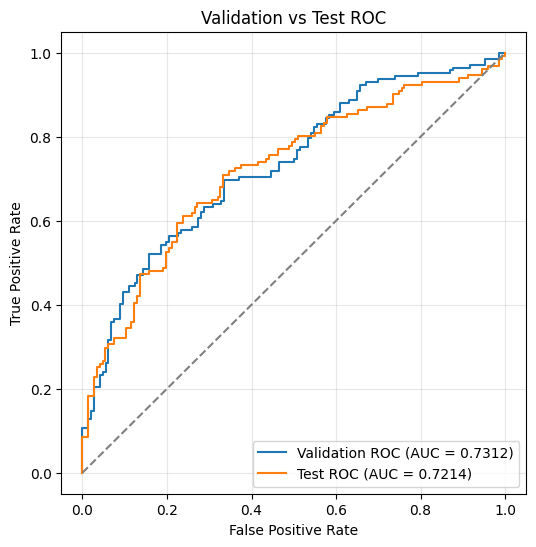

In [11]:
def collect_predictions(ds, model):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        pb = model.predict(xb, verbose=0).reshape(-1)
        y_true.append(yb.numpy().reshape(-1))
        y_prob.append(pb)
    return np.concatenate(y_true).astype("int32"), np.concatenate(y_prob)

val_true, val_prob = collect_predictions(val_ds_prep, best_model)
test_true, test_prob = collect_predictions(test_ds_prep, best_model)
test_pred = (test_prob >= 0.5).astype("int32")

print("Positive class for ROC/AUC:", class_names[1])
print("First 20 val_true:", val_true[:20])
print("First 20 val_prob:", np.round(val_prob[:20], 4))
print("First 20 test_true:", test_true[:20])
print("First 20 test_prob:", np.round(test_prob[:20], 4))
print("Validation probability range:", float(val_prob.min()), float(val_prob.max()))
print("Validation probability mean/std:", float(val_prob.mean()), float(val_prob.std()))
print("Test probability range:", float(test_prob.min()), float(test_prob.max()))
print("Test probability mean/std:", float(test_prob.mean()), float(test_prob.std()))

val_fpr, val_tpr, _ = roc_curve(val_true, val_prob)
test_fpr, test_tpr, _ = roc_curve(test_true, test_prob)
val_auc = roc_auc_score(val_true, val_prob)
test_auc = roc_auc_score(test_true, test_prob)
test_acc = accuracy_score(test_true, test_pred)
cm = confusion_matrix(test_true, test_pred)

print(f"Validation AUC: {val_auc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(test_true, test_pred, target_names=class_names))

plt.figure(figsize=(6, 6))
plt.plot(val_fpr, val_tpr, label=f"Validation ROC (AUC = {val_auc:.4f})")
plt.plot(test_fpr, test_tpr, label=f"Test ROC (AUC = {test_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation vs Test ROC")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


In [12]:
import csv
import json
from pathlib import Path
from sklearn.metrics import precision_score, recall_score, f1_score

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

model_name = "resnet50"


def save_predictions_csv(y_true, y_prob, split):
    path = results_dir / f"{model_name}_{split}_predictions.csv"
    with path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["y_true", "y_prob"])
        for yt, yp in zip(y_true, y_prob):
            writer.writerow([int(yt), float(yp)])
    print("Saved:", path)


metrics_summary = {
    "model": model_name,
    "validation_auc": float(val_auc),
    "test_auc": float(test_auc),
    "test_accuracy": float(test_acc),
    "test_precision": float(precision_score(test_true, test_pred)),
    "test_recall": float(recall_score(test_true, test_pred)),
    "test_f1": float(f1_score(test_true, test_pred)),
}

save_predictions_csv(val_true, val_prob, "val")
save_predictions_csv(test_true, test_prob, "test")

metrics_path = results_dir / f"{model_name}_metrics.json"
metrics_path.write_text(json.dumps(metrics_summary, indent=2), encoding="utf-8")
print("Saved:", metrics_path)
print(metrics_summary)


Saved: results/resnet50_val_predictions.csv
Saved: results/resnet50_test_predictions.csv
Saved: results/resnet50_metrics.json
{'model': 'resnet50', 'validation_auc': 0.7311885008682228, 'test_auc': 0.7214000103858338, 'test_accuracy': 0.6798561151079137, 'test_precision': 0.6458333333333334, 'test_recall': 0.7099236641221374, 'test_f1': 0.6763636363636364}


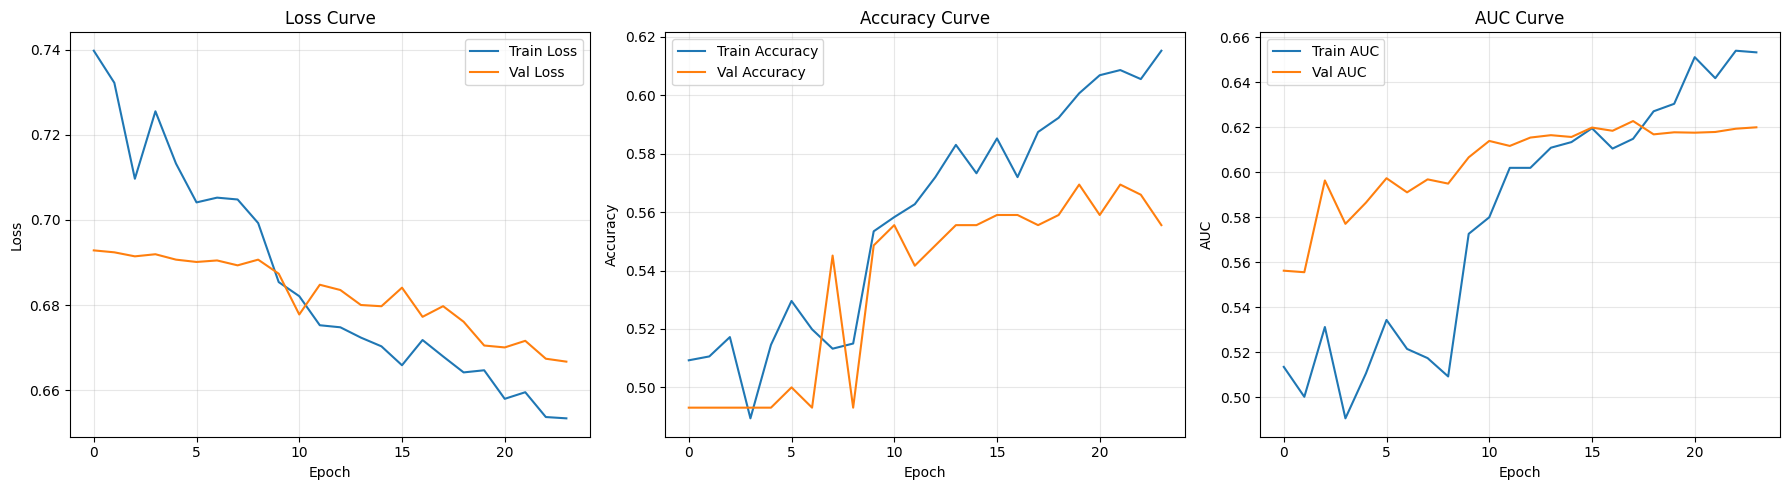

In [13]:
def merge_history(*histories):
    merged = {}
    for h in histories:
        if h is None:
            continue
        for k, v in h.history.items():
            merged.setdefault(k, []).extend(v)
    return merged

all_history = merge_history(history1, history2)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(all_history["loss"], label="Train Loss")
plt.plot(all_history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
train_acc_key = "acc" if "acc" in all_history else "accuracy"
val_acc_key = "val_acc" if "val_acc" in all_history else "val_accuracy"
plt.plot(all_history[train_acc_key], label="Train Accuracy")
plt.plot(all_history[val_acc_key], label="Val Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(all_history["auc"], label="Train AUC")
plt.plot(all_history["val_auc"], label="Val AUC")
plt.title("AUC Curve")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
